# Apple Weekly Stock Price Prediction Using Forex Indicators

## End-to-End Data Analytics + Machine Learning Portfolio Project

### Project Goal
This notebook predicts **Apple Inc. (AAPL)'s next-week closing price** using:

1. Historical Apple stock price data  
2. Technical indicators  
3. Forex/macroeconomic context through the **Nominal Broad U.S. Dollar Index**  
4. Machine learning regression models  
5. Finance and business interpretation  

### Why this project is portfolio-worthy
Instead of only using Apple’s past price, this project combines:
- Market behaviour: price, volume, returns
- Technical signals: moving averages, RSI, MACD, volatility
- Forex/macro conditions: U.S. dollar strength

This makes the project stronger for a data analytics / data science portfolio.

### Important Disclaimer
This project is for educational and portfolio purposes only. It is **not financial advice**.


# 1. Problem Statement

Stock prices are influenced by historical price behaviour, investor sentiment, macroeconomic conditions, currency movements, earnings expectations, and external news.

The objective of this project is to build a machine learning pipeline that predicts:

> **Apple's adjusted closing price 5 trading days into the future**

Since most trading weeks have about 5 market days, this is treated as a **next-week price prediction** task.

### Target Variable
`Next_Week_Close = Apple Close price shifted 5 trading days ahead`

### Business Question
Can historical stock behaviour and forex-related macro indicators help estimate Apple's short-term price movement?


# 2. Dataset Sources

This notebook uses live public data sources that can be pulled directly into Python.

## Apple Stock Data
- Source: Yahoo Finance, accessed using `yfinance`
- Ticker: `AAPL`
- Features: Open, High, Low, Close, Volume

## Forex / Macro Data
- Source: FRED, Federal Reserve Bank of St. Louis
- Series: `DTWEXBGS`
- Name: Nominal Broad U.S. Dollar Index
- Frequency: Daily
- Meaning: A broad trade-weighted measure of the U.S. dollar's value

### Why use USD Index for Apple?
Apple is a global company. A stronger U.S. dollar can affect international revenue when foreign earnings are translated back into dollars. Therefore, USD strength may provide useful macroeconomic context.


# 3. Install Required Libraries

Run this cell once if the libraries are not installed.


In [1]:
# Install required libraries
!pip install yfinance pandas numpy matplotlib scikit-learn xgboost pandas_datareader -q

# 4. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from pandas_datareader import data as pdr

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBRegressor
    xgboost_available = True
except Exception:
    xgboost_available = False
    print("XGBoost is not available. The notebook will continue without it.")

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)


# 5. Project Configuration

You can change the dates below if you want a different study period.

For a portfolio project, starting from 2015 gives enough historical data while keeping the project modern.


In [3]:
STOCK_TICKER = "AAPL"
USD_INDEX_SERIES = "DTWEXBGS"

START_DATE = "2015-01-01"
END_DATE = None  # None means download latest available data

FORECAST_HORIZON = 5  # 5 trading days = approximately one week

# 6. Download Apple Stock Data

This step downloads Apple stock data from Yahoo Finance using `yfinance`.


In [4]:
apple = yf.download(
    STOCK_TICKER,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False
)

apple.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.192602,24.659504,23.754466,24.648440,212818400
2015-01-05,23.511065,24.042138,23.325190,23.962477,257142000
2015-01-06,23.513268,23.772165,23.152579,23.575226,263188400
2015-01-07,23.842985,23.942561,23.610640,23.721280,160423600
2015-01-08,24.759085,24.816618,24.053199,24.170479,237458000


## Check Apple Dataset Shape and Missing Values

In [5]:
print("Apple data shape:", apple.shape)
print("\nMissing values:")
print(apple.isna().sum())

Apple data shape: (2873, 5)

Missing values:
Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


# 7. Clean Apple Stock Data

Sometimes `yfinance` returns multi-level columns depending on the version and ticker format.  
This cell makes the dataset clean and simple.


In [6]:
# Flatten columns if yfinance returns multi-index columns
if isinstance(apple.columns, pd.MultiIndex):
    apple.columns = apple.columns.get_level_values(0)

apple = apple.reset_index()

# Keep only required columns
required_cols = ["Date", "Open", "High", "Low", "Close", "Volume"]
apple = apple[required_cols]

apple["Date"] = pd.to_datetime(apple["Date"])
apple = apple.sort_values("Date").reset_index(drop=True)

apple.head()

Price,Date,Open,High,Low,Close,Volume
0,2015-01-02,24.648440,24.659504,23.754466,24.192602,212818400
1,2015-01-05,23.962477,24.042138,23.325190,23.511065,257142000
2,2015-01-06,23.575226,23.772165,23.152579,23.513268,263188400
3,2015-01-07,23.721280,23.942561,23.610640,23.842985,160423600
4,2015-01-08,24.170479,24.816618,24.053199,24.759085,237458000


# 8. Download Forex / Macro Data from FRED

We use the Nominal Broad U.S. Dollar Index as a forex-related macroeconomic variable.


In [8]:
import urllib.request

try:
    urllib.request.urlopen("https://www.google.com", timeout=5)
    print("✅ Internet access works")
except Exception as e:
    print("❌ No internet access:", e)

✅ Internet access works


In [12]:
import requests

url = "https://api.stlouisfed.org/fred/series/observations"
params = {
    "series_id": "DTWEXBGS",
    "api_key": "22cb4ff40f7971de325501ec1cb5e285",  # FRED requested API key
    "file_type": "json",
    "observation_start": START_DATE
}

response = requests.get(url, params=params, timeout=15)
data = response.json()

usd_index = pd.DataFrame(data["observations"])[["date", "value"]]
usd_index.columns = ["Date", "USD_Index"]
usd_index["Date"] = pd.to_datetime(usd_index["Date"])
usd_index["USD_Index"] = pd.to_numeric(usd_index["USD_Index"], errors="coerce")
usd_index = usd_index.dropna().sort_values("Date").reset_index(drop=True)

print("USD Index shape:", usd_index.shape)
usd_index.head()

USD Index shape: (2844, 2)


,Date,USD_Index
0,2015-01-02,102.9027
1,2015-01-05,103.4976
2,2015-01-06,103.2938
3,2015-01-07,103.6316
4,2015-01-08,103.2799


In [13]:
print(data)

{'realtime_start': '2026-06-02', 'realtime_end': '2026-06-02', 'observation_start': '2015-01-01', 'observation_end': '9999-12-31', 'units': 'lin', 'output_type': 1, 'file_type': 'json', 'order_by': 'observation_date', 'sort_order': 'asc', 'count': 2977, 'offset': 0, 'limit': 100000, 'observations': [{'realtime_start': '2026-06-02', 'realtime_end': '2026-06-02', 'date': '2015-01-01', 'value': '.'}, {'realtime_start': '2026-06-02', 'realtime_end': '2026-06-02', 'date': '2015-01-02', 'value': '102.9027'}, {'realtime_start': '2026-06-02', 'realtime_end': '2026-06-02', 'date': '2015-01-05', 'value': '103.4976'}, {'realtime_start': '2026-06-02', 'realtime_end': '2026-06-02', 'date': '2015-01-06', 'value': '103.2938'}, {'realtime_start': '2026-06-02', 'realtime_end': '2026-06-02', 'date': '2015-01-07', 'value': '103.6316'}, {'realtime_start': '2026-06-02', 'realtime_end': '2026-06-02', 'date': '2015-01-08', 'value': '103.2799'}, {'realtime_start': '2026-06-02', 'realtime_end': '2026-06-02', '

## Clean USD Index Data

In [16]:
print(usd_index.columns.tolist())
print(usd_index.head())

['level_0', 'index', 'Date', 'USD_Index']
   level_0  index       Date  USD_Index
0        0      0 2015-01-02   102.9027
1        1      1 2015-01-05   103.4976
2        2      2 2015-01-06   103.2938
3        3      3 2015-01-07   103.6316
4        4      4 2015-01-08   103.2799


In [17]:
usd_index = usd_index[["Date", "USD_Index"]].copy()

usd_index["Date"] = pd.to_datetime(usd_index["Date"])
usd_index = usd_index.sort_values("Date").reset_index(drop=True)

print("USD index shape:", usd_index.shape)
usd_index.head()

USD index shape: (2844, 2)


,Date,USD_Index
0,2015-01-02,102.9027
1,2015-01-05,103.4976
2,2015-01-06,103.2938
3,2015-01-07,103.6316
4,2015-01-08,103.2799


# 9. Merge Apple and USD Index Data

Financial markets and macroeconomic series may have different holiday calendars.  
We merge on date and forward-fill missing USD values.


In [18]:
df = pd.merge(apple, usd_index, on="Date", how="left")

# Forward fill macro values because FRED may not publish values for every stock trading day
df["USD_Index"] = df["USD_Index"].ffill()

df = df.dropna().reset_index(drop=True)

df.head()

,Date,Open,High,Low,Close,Volume,USD_Index
0,2015-01-02,24.648440,24.659504,23.754466,24.192602,212818400,102.9027
1,2015-01-05,23.962477,24.042138,23.325190,23.511065,257142000,103.4976
2,2015-01-06,23.575226,23.772165,23.152579,23.513268,263188400,103.2938
3,2015-01-07,23.721280,23.942561,23.610640,23.842985,160423600,103.6316
4,2015-01-08,24.170479,24.816618,24.053199,24.759085,237458000,103.2799


In [19]:
print("Merged dataset shape:", df.shape)
print("\nMissing values after merge:")
print(df.isna().sum())

Merged dataset shape: (2873, 7)

Missing values after merge:
Date         0
Open         0
High         0
Low          0
Close        0
Volume       0
USD_Index    0
dtype: int64


# 10. Exploratory Data Analysis

EDA helps us understand price trends, volatility, volume behaviour, and possible relationships between Apple and USD strength.


## 10.1 Apple Closing Price Over Time

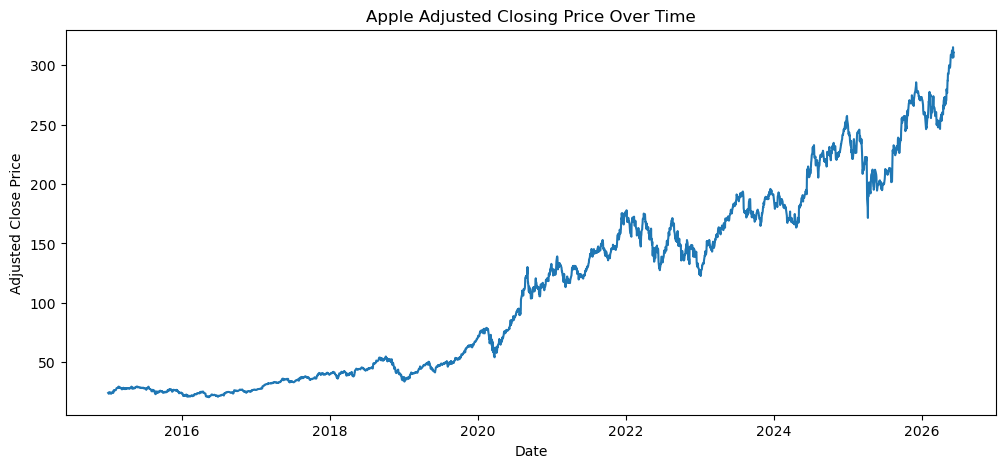

In [20]:
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Close"])
plt.title("Apple Adjusted Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.show()

### Interpretation
This chart shows the long-term movement of Apple's adjusted closing price.  
A portfolio-level interpretation should discuss whether the price shows:
- Long-term upward trend
- Periods of drawdown
- Volatile phases
- Recent acceleration or weakness


## 10.2 Apple Trading Volume Over Time

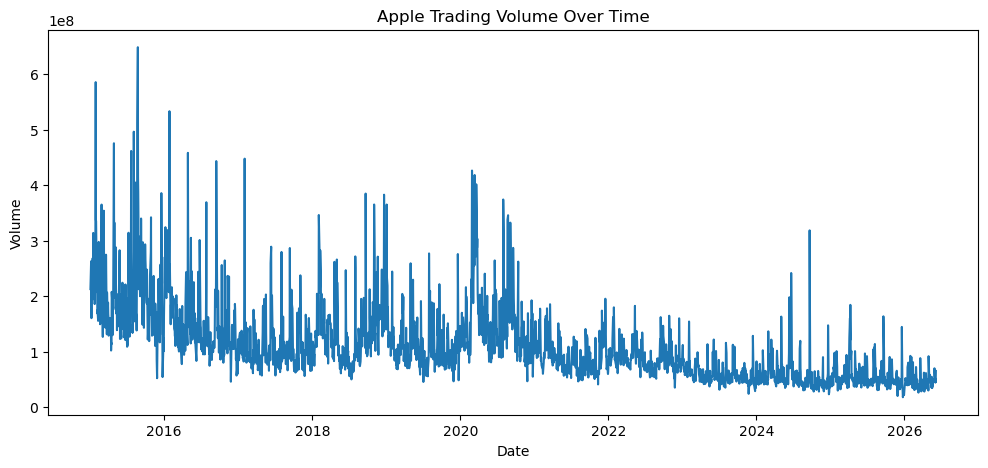

In [21]:
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Volume"])
plt.title("Apple Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

### Interpretation
Volume reflects market participation.  
High-volume periods may indicate earnings events, product launches, macroeconomic shocks, or strong investor reaction.


## 10.3 USD Index Over Time

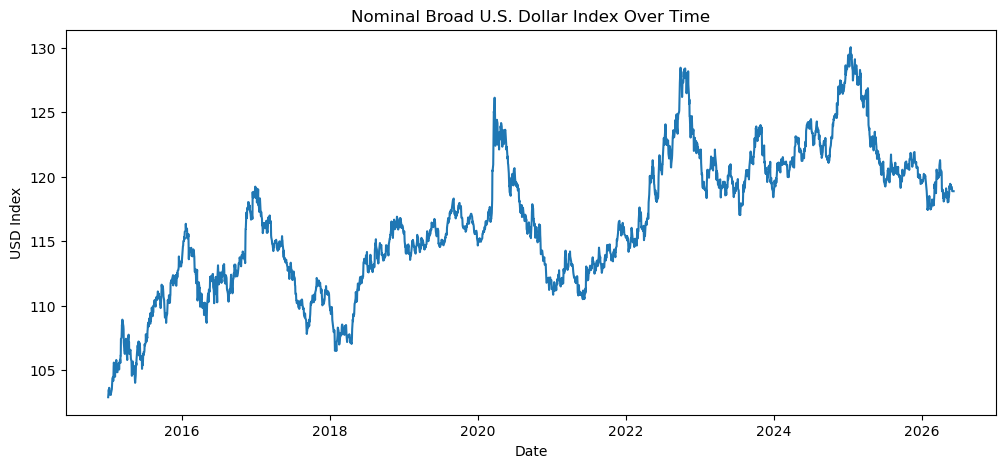

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["USD_Index"])
plt.title("Nominal Broad U.S. Dollar Index Over Time")
plt.xlabel("Date")
plt.ylabel("USD Index")
plt.show()

### Interpretation
A rising USD Index means the U.S. dollar is strengthening relative to a broad basket of currencies.  
For multinational companies like Apple, USD strength may influence international revenue translation.


## 10.4 Apple Price vs USD Index

Since Apple and the USD Index have different scales, we normalize both to start at 100.


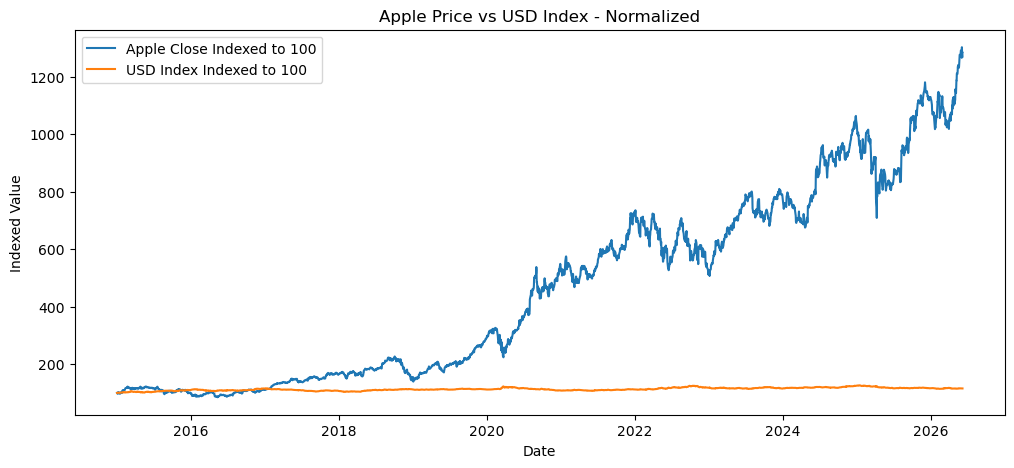

In [23]:
df["Apple_Normalized"] = (df["Close"] / df["Close"].iloc[0]) * 100
df["USD_Normalized"] = (df["USD_Index"] / df["USD_Index"].iloc[0]) * 100

plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Apple_Normalized"], label="Apple Close Indexed to 100")
plt.plot(df["Date"], df["USD_Normalized"], label="USD Index Indexed to 100")
plt.title("Apple Price vs USD Index - Normalized")
plt.xlabel("Date")
plt.ylabel("Indexed Value")
plt.legend()
plt.show()

# 11. Feature Engineering

Feature engineering transforms raw price data into meaningful predictive signals.

We create:
- Returns
- Moving averages
- Volatility
- Price range
- Momentum indicators
- Forex/USD features


In [ ]:
# Daily returns
df["Daily_Return"] = df["Close"].pct_change()

# Moving averages
df["MA_5"] = df["Close"].rolling(window=5).mean()
df["MA_10"] = df["Close"].rolling(window=10).mean()
df["MA_20"] = df["Close"].rolling(window=20).mean()
df["MA_50"] = df["Close"].rolling(window=50).mean()

# Volume moving average
df["Volume_MA_10"] = df["Volume"].rolling(window=10).mean()

# Volatility
df["Volatility_5"] = df["Daily_Return"].rolling(window=5).std()
df["Volatility_10"] = df["Daily_Return"].rolling(window=10).std()
df["Volatility_20"] = df["Daily_Return"].rolling(window=20).std()

# Price behaviour
df["Price_Range"] = df["High"] - df["Low"]
df["Open_Close_Diff"] = df["Close"] - df["Open"]
df["High_Low_Pct"] = (df["High"] - df["Low"]) / df["Close"]

# USD index features
df["USD_Return"] = df["USD_Index"].pct_change()
df["USD_MA_5"] = df["USD_Index"].rolling(window=5).mean()
df["USD_MA_10"] = df["USD_Index"].rolling(window=10).mean()
df["USD_MA_20"] = df["USD_Index"].rolling(window=20).mean()

df.head()

# 12. Add RSI Indicator

RSI stands for Relative Strength Index.  
It is commonly used to identify overbought or oversold conditions.


In [ ]:
def calculate_rsi(series, window=14):
    """
    Wilder's smoothed RSI (industry standard).
    Uses EWM with com=window-1 instead of a simple rolling mean,
    which matches the original Wilder (1978) definition.
    """
    delta = series.diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    # Wilder's smoothing: equivalent to EMA with alpha = 1/window
    avg_gain = gain.ewm(com=window - 1, min_periods=window, adjust=False).mean()
    avg_loss = loss.ewm(com=window - 1, min_periods=window, adjust=False).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    return rsi

df["RSI_14"] = calculate_rsi(df["Close"], window=14)

df[["Date", "Close", "RSI_14"]].tail()


# 13. Add MACD Indicator

MACD stands for Moving Average Convergence Divergence.  
It captures momentum by comparing short-term and long-term exponential moving averages.


In [ ]:
df["EMA_12"] = df["Close"].ewm(span=12, adjust=False).mean()
df["EMA_26"] = df["Close"].ewm(span=26, adjust=False).mean()

df["MACD"] = df["EMA_12"] - df["EMA_26"]
df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()
df["MACD_Histogram"] = df["MACD"] - df["MACD_Signal"]

df[["Date", "Close", "MACD", "MACD_Signal", "MACD_Histogram"]].tail()

# 14. Create Target Variable

We predict Apple's close price 5 trading days into the future.

This represents an approximate next-week prediction.


In [ ]:
df["Next_Week_Close"] = df["Close"].shift(-FORECAST_HORIZON)

# Also create direction target for business interpretation
df["Next_Week_Direction"] = np.where(df["Next_Week_Close"] > df["Close"], 1, 0)

df[["Date", "Close", "Next_Week_Close", "Next_Week_Direction"]].tail(10)

# 15. Final Cleaning Before Modelling

Rows with rolling-window missing values are removed.


In [ ]:
df_model = df.dropna().reset_index(drop=True)

print("Final modelling dataset shape:", df_model.shape)
df_model.head()

# 16. Select Features and Target

In [ ]:
features = [
    "Open", "High", "Low", "Close", "Volume",
    "Daily_Return",
    "MA_5", "MA_10", "MA_20", "MA_50",
    "Volume_MA_10",
    "Volatility_5", "Volatility_10", "Volatility_20",
    "Price_Range", "Open_Close_Diff", "High_Low_Pct",
    "USD_Index", "USD_Return", "USD_MA_5", "USD_MA_10", "USD_MA_20",
    "RSI_14",
    "MACD", "MACD_Signal", "MACD_Histogram"
]

X = df_model[features]
y = df_model["Next_Week_Close"]

X.head()

# 17. Time-Based Train-Test Split

For time-series data, we should not randomly shuffle the rows.

The first 80% of the data is used for training, and the final 20% is used for testing.


In [ ]:
split_index = int(len(df_model) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

test_dates = df_model["Date"].iloc[split_index:]
test_current_close = df_model["Close"].iloc[split_index:]

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

# 18. Build Machine Learning Models

We compare multiple regression models.

Models:
1. Linear Regression
2. Ridge Regression
3. Random Forest Regressor
4. Gradient Boosting Regressor
5. XGBoost Regressor, if installed


In [ ]:
# Linear models are wrapped in a Pipeline with StandardScaler.
# This is necessary because Linear Regression and Ridge are sensitive
# to feature scale — Volume (billions) vs Daily_Return (tiny decimals)
# would otherwise distort the coefficient magnitudes.
# Tree-based models are scale-invariant, so no scaler is needed for them.

models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    "Random Forest": RandomForestRegressor(
        n_estimators=250,
        max_depth=8,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

if xgboost_available:
    models["XGBoost"] = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective="reg:squarederror"
    )

models.keys()


# 19. Train and Evaluate Models

Evaluation metrics:
- **MAE**: Mean Absolute Error
- **RMSE**: Root Mean Squared Error
- **R² Score**: Proportion of variance explained by the model
- **Direction Accuracy**: Whether the model correctly predicts up/down movement


In [ ]:
results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    actual_direction = np.where(y_test.values > test_current_close.values, 1, 0)
    predicted_direction = np.where(predictions > test_current_close.values, 1, 0)
    direction_accuracy = np.mean(actual_direction == predicted_direction)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2,
        "Direction Accuracy": direction_accuracy
    })

    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values(by="RMSE").reset_index(drop=True)
results_df


# 20. Select Best Model

The best model is selected based on the lowest RMSE.


In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)

# 21. Plot Actual vs Predicted Next-Week Prices

In [ ]:
best_predictions = best_model.predict(X_test)

plt.figure(figsize=(12, 5))
plt.plot(test_dates, y_test.values, label="Actual Next-Week Close")
plt.plot(test_dates, best_predictions, label="Predicted Next-Week Close")
plt.title(f"Actual vs Predicted Apple Next-Week Close - {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

# 22. Prediction Error Over Time

In [ ]:
error_df = pd.DataFrame({
    "Date": test_dates.values,
    "Actual": y_test.values,
    "Predicted": best_predictions
})

error_df["Error"] = error_df["Actual"] - error_df["Predicted"]
error_df["Absolute_Error"] = error_df["Error"].abs()

plt.figure(figsize=(12, 5))
plt.plot(error_df["Date"], error_df["Error"])
plt.axhline(0, linestyle="--")
plt.title("Prediction Error Over Time")
plt.xlabel("Date")
plt.ylabel("Actual - Predicted")
plt.show()

error_df.tail()

# 23. Feature Importance

For tree-based models, feature importance helps explain what the model used most.


In [ ]:
# For Pipeline models, the actual estimator lives at model[-1] or model.named_steps['model'].
# For plain estimators (Random Forest, XGBoost, Gradient Boosting), hasattr works directly.

def get_estimator(model):
    """Unwrap a Pipeline to get the underlying estimator, if needed."""
    if isinstance(model, Pipeline):
        return model[-1]
    return model

estimator = get_estimator(best_model)

if hasattr(estimator, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Feature": features,
        "Importance": estimator.feature_importances_
    }).sort_values(by="Importance", ascending=False).reset_index(drop=True)

    display(importance_df.head(15))

    top_features = importance_df.head(15)

    plt.figure(figsize=(10, 6))
    plt.barh(top_features["Feature"], top_features["Importance"])
    plt.title("Top 15 Feature Importances")
    plt.xlabel("Importance")
    plt.gca().invert_yaxis()
    plt.show()
else:
    print("Feature importance is not available for this model type.")


# 24. Predict Next Week's Apple Closing Price

This section uses the latest available row of features and predicts Apple's closing price 5 trading days ahead.


In [ ]:
latest_features = X.iloc[[-1]]
latest_date = df_model["Date"].iloc[-1]
current_price = df_model["Close"].iloc[-1]

next_week_prediction = best_model.predict(latest_features)[0]

expected_change = next_week_prediction - current_price
expected_change_pct = (expected_change / current_price) * 100

print("Latest available date:", latest_date.date())
print("Current Apple close:", round(current_price, 2))
print("Predicted Apple close next week:", round(next_week_prediction, 2))
print("Expected change:", round(expected_change, 2))
print("Expected percentage change:", round(expected_change_pct, 2), "%")

# 25. Business Signal

This converts the numerical prediction into a simple business interpretation.

Thresholds:
- Above +2% = Bullish
- Below -2% = Bearish
- Between -2% and +2% = Neutral


In [ ]:
if expected_change_pct > 2:
    signal = "Bullish"
    interpretation = "The model predicts a meaningful upward movement over the next week."
elif expected_change_pct < -2:
    signal = "Bearish"
    interpretation = "The model predicts a meaningful downward movement over the next week."
else:
    signal = "Neutral"
    interpretation = "The model predicts limited price movement over the next week."

print("Signal:", signal)
print("Business Interpretation:", interpretation)

# 26. Finance and Business Interpretation

## What the model tells us
The model estimates Apple's next-week closing price using a combination of technical, price-based, volume-based, and forex-related features.

## Why USD strength matters
Apple earns revenue globally. When the U.S. dollar strengthens, foreign revenues may translate into fewer dollars. This can affect investor expectations and valuation.

## Why technical indicators matter
Technical indicators such as moving averages, RSI, MACD, and volatility capture recent market behaviour. These features help the model identify momentum, trend strength, and short-term risk.

## How an analyst could use this
This model can support:
- Short-term market monitoring
- Risk awareness
- Scenario analysis
- Investment research dashboards

## What an analyst should not do
The prediction should not be used as a standalone trading decision. It does not include:
- Earnings-call sentiment
- News sentiment
- Product launch announcements
- Analyst upgrades/downgrades
- Geopolitical shocks
- Interest-rate decisions


# 27. Limitations

1. Stock markets are noisy and difficult to predict.
2. The model uses historical data, which may not capture sudden news events.
3. The forecast horizon is short.
4. Technical indicators are derived from price, so they may not add completely independent information.
5. USD Index is useful macro context, but it is not the only macroeconomic driver.
6. The model does not include sentiment analysis or company fundamentals.
7. Past performance does not guarantee future performance.


# 28. Possible Improvements

To make this project even stronger, you could add:

1. News sentiment analysis  
2. Apple earnings dates  
3. Interest rates from FRED  
4. S&P 500 or NASDAQ index data  
5. Walk-forward validation  
6. LSTM or temporal deep learning model  
7. Streamlit dashboard  
8. Model explainability with SHAP  
9. Backtesting strategy  
10. Buy/Sell/Hold classification model  


# 29. Final Conclusion

This project built an end-to-end machine learning pipeline to predict Apple’s next-week adjusted closing price. The workflow included data collection, cleaning, EDA, feature engineering, model training, model evaluation, forecasting, and finance/business interpretation.

The project demonstrated that technical indicators and forex-related macroeconomic variables can be combined to create a more context-aware stock forecasting model. The final output includes both a numerical forecast and a business-friendly signal.

This makes the project suitable for a data analytics, data science, or financial analytics portfolio.


# 30. GitHub README Text

You can copy this into your GitHub README.

```markdown
# Apple Weekly Stock Price Prediction Using Forex Indicators

## Project Overview
This project predicts Apple Inc.'s next-week adjusted closing price using historical stock data, technical indicators, and forex-related macroeconomic features.

## Objective
To build an end-to-end data analytics and machine learning pipeline for short-term stock price forecasting.

## Dataset
- Apple stock data from Yahoo Finance
- Nominal Broad U.S. Dollar Index from FRED

## Tools Used
- Python
- Jupyter Notebook
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- XGBoost
- yfinance
- pandas_datareader

## Methodology
1. Data collection
2. Data cleaning
3. Exploratory data analysis
4. Feature engineering
5. Target creation
6. Model training
7. Model evaluation
8. Forecasting
9. Business interpretation

## Models Used
- Linear Regression
- Ridge Regression
- Random Forest Regressor
- Gradient Boosting Regressor
- XGBoost Regressor

## Evaluation Metrics
- MAE
- RMSE
- R² Score
- Direction Accuracy

## Business Value
This project demonstrates how market data and macroeconomic indicators can be used to support short-term financial analytics.

## Disclaimer
This project is for educational and portfolio purposes only. It is not financial advice.
```


# 31. CV / Portfolio Bullet

You can use this bullet on your CV:

> Built an end-to-end financial analytics project to predict Apple’s next-week stock price using Python, Yahoo Finance stock data, FRED forex indicators, technical analysis, and machine learning. Engineered features including moving averages, RSI, MACD, volatility, and USD Index trends; compared regression models using MAE, RMSE, R², and directional accuracy; and translated model outputs into business-friendly investment signals.
